# Notebook 02: DEM Preprocessing & Reprojection

## Objective
Reproject DEM rasters from WGS 84 (EPSG:4326) to UTM 33S (EPSG:32733), enforce exactly 30 m pixel resolution, handle NoData values, and validate quality through systematic QA checks.

## Key Processing Steps
1. **Load source rasters** in WGS 84 with metadata verification
2. **Calculate reprojection parameters** for UTM 33S target CRS
3. **Enforce exactly 30 m grid** by recalculating dimensions and transform
4. **Apply cubic convolution resampling** (hydrologically appropriate for DEM)
5. **Convert NaN → -9999** NoData sentinel for ArcGIS compatibility
6. **Execute 6-point QA framework** (extent, statistics, NoData propagation, CRS, slope integrity, visual inspection)
7. **Save validated rasters** to `data/processed/`
8. **Export processing log** (JSON metadata)

## Methodology Notes
- **Resampling**: Cubic convolution preserves elevation surface gradients necessary for D8 flow direction
- **Grid Enforcement**: Exact 30 m pixel (not ~30 m) ensures reproducibility and downstream consistency
- **NoData Handling**: Internal NaN → external -9999 for ArcGIS integration readiness
- **QA Philosophy**: Simple 6-check framework covers essential validation without over-engineering edge cases

In [1]:
# Import Required Libraries
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Define Paths and Parameters
PROJECT_ROOT = Path.cwd().parent.parent  # Navigate to workspace root
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

# Create output directories if they don't exist
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

# Define processing parameters
TARGET_CRS = 'EPSG:32733'  # UTM Zone 33S
TARGET_PIXEL_SIZE = 30  # meters (enforce exactly 30 m)
NODATA_VALUE = -9999  # Sentinel value for ArcGIS compatibility
RESAMPLING_METHOD = Resampling.cubic  # Cubic convolution for continuous surfaces

# Define study area file names
#STUDY_AREAS = {
#    'windhoek': 'copernicus_DEM_Namibia_windhoek.tif',
#    'oshakati': 'copernicus_DEM_Namibia_cuvelai.tif'
#}

STUDY_AREAS = {
    'windhoek': 'copernicus_DEM_Namibia_small_WDH.tif',
    'oshakati': 'copernicus_DEM_Namibia_small_OSH.tif'
}

# Build full file paths
path_windhoek_wgs84 = DATA_RAW / STUDY_AREAS['windhoek']
path_oshakati_wgs84 = DATA_RAW / STUDY_AREAS['oshakati']
path_windhoek_validated = DATA_PROCESSED / 'windhoek_utm33s_validated.tif'
path_oshakati_validated = DATA_PROCESSED / 'oshakati_utm33s_validated.tif'

print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ Raw data path: {DATA_RAW}")
print(f"✓ Output path: {DATA_PROCESSED}")
print(f"✓ Target CRS: {TARGET_CRS}")
print(f"✓ Target pixel size: {TARGET_PIXEL_SIZE} m")
print(f"\nInput files:")
print(f"  - Windhoek: {path_windhoek_wgs84.name} (exists: {path_windhoek_wgs84.exists()})")
print(f"  - Oshakati: {path_oshakati_wgs84.name} (exists: {path_oshakati_wgs84.exists()})")

✓ Project root: /Users/jacobsmacbookpro/Namibia_python
✓ Raw data path: /Users/jacobsmacbookpro/Namibia_python/data/raw
✓ Output path: /Users/jacobsmacbookpro/Namibia_python/data/processed
✓ Target CRS: EPSG:32733
✓ Target pixel size: 30 m

Input files:
  - Windhoek: copernicus_DEM_Namibia_small_WDH.tif (exists: True)
  - Oshakati: copernicus_DEM_Namibia_small_OSH.tif (exists: True)


In [3]:
# Load and Inspect Source Rasters (WGS 84)
print("=" * 70)
print("LOAD SOURCE RASTERS IN WGS 84")
print("=" * 70)

source_metadata = {}

for location_key, filename in STUDY_AREAS.items():
    source_path = DATA_RAW / filename
    
    with rasterio.open(source_path) as src:
        # Extract metadata
        metadata = {
            'location': location_key,
            'filename': filename,
            'crs': src.crs,
            'width': src.width,
            'height': src.height,
            'bounds': src.bounds,  # (left, bottom, right, top)
            'resolution': src.res,  # (pixel_width, pixel_height)
            'dtype': src.dtypes[0],
            'nodata': src.nodata,
        }
        
        # Read data and compute statistics
        data = src.read(1)
        valid_data = data[~np.isnan(data)]
        
        metadata['stats'] = {
            'min': float(np.nanmin(data)),
            'max': float(np.nanmax(data)),
            'mean': float(np.nanmean(data)),
            'std': float(np.nanstd(data)),
            'nan_percent': float(100 * np.sum(np.isnan(data)) / data.size),
            'valid_pixels': int(np.sum(~np.isnan(data))),
            'total_pixels': int(data.size),
        }
        
        source_metadata[location_key] = metadata
        
        # Print summary
        print(f"\n{location_key.upper()}:")
        print(f"  CRS: {metadata['crs']}")
        print(f"  Dimensions: {metadata['width']} x {metadata['height']} pixels")
        print(f"  Pixel resolution: {metadata['resolution'][0]:.6f}° x {metadata['resolution'][1]:.6f}° (WGS 84 degrees)")
        print(f"  Elevation - Min: {metadata['stats']['min']:.2f} m, Max: {metadata['stats']['max']:.2f} m")
        print(f"  Elevation - Mean: {metadata['stats']['mean']:.2f} m, Std Dev: {metadata['stats']['std']:.2f} m")
        print(f"  NoData cells: {metadata['stats']['nan_percent']:.2f}%")

print("\n✓ Source raster inspection complete")

LOAD SOURCE RASTERS IN WGS 84

WINDHOEK:
  CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
  Dimensions: 644 x 394 pixels
  Pixel resolution: 0.000269° x 0.000269° (WGS 84 degrees)
  Elevation - Min: 1474.18 m, Max: 2053.15 m
  Elevation - Mean: 1633.72 m, Std Dev: 77.99 m
  NoData cells: 2.83%

OSHAKATI:
  CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
  Dimensions: 296 x 248 pixels
  Pixel resolution: 0.000269° x 0.000269° (WGS 84 degrees)
  Elevation - Min: 1087.50 m, Max: 1105.44 m
  Elevation - Mean: 1094.36 m, Std Dev: 1.45 m
  NoData cells: 0.73%

✓ Source raster inspection complete


In [4]:
# Define Reprojection Function with Exact 30 m Grid Enforcement
def reproject_dem_exact_30m(src_path, dst_path, target_crs, target_pixel_size, 
                             resampling_method, nodata_value):
    """
    Reproject DEM to target CRS with EXACT pixel size enforcement.
    Avoids PROJ database issues by using pyproj directly.
    
    Parameters:
    -----------
    src_path : Path
        Input raster path (WGS 84)
    dst_path : Path
        Output raster path (UTM 33S)
    target_crs : str
        Target CRS code (e.g., 'EPSG:32733')
    target_pixel_size : int
        Desired pixel size in meters (e.g., 30)
    resampling_method : rasterio.enums.Resampling
        Resampling method (e.g., Resampling.cubic)
    nodata_value : int
        NoData sentinel value for output
    
    Returns:
    --------
    dict : Reprojection metadata (bounds, dimensions, CRS)
    """
    from pyproj import Transformer
    
    # UTM 33S WKT string (to avoid PROJ database lookups)
    utm33s_wkt = 'PROJCS["WGS 84 / UTM zone 33S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1]]'
    
    with rasterio.open(src_path) as src:
        # Step 1: Use pyproj to transform bounds (avoids rasterio's PROJ database lookup)
        transformer = Transformer.from_crs("EPSG:4326", "EPSG:32733", always_xy=True)
        
        # Transform all 4 corners to get precise UTM bounds
        bounds_wgs84 = src.bounds
        corners_wgs84 = [
            (bounds_wgs84.left, bounds_wgs84.bottom),   # lower-left
            (bounds_wgs84.right, bounds_wgs84.bottom),  # lower-right
            (bounds_wgs84.right, bounds_wgs84.top),     # upper-right
            (bounds_wgs84.left, bounds_wgs84.top),      # upper-left
        ]
        
        corners_utm = [transformer.transform(lon, lat) for lon, lat in corners_wgs84]
        
        # Extract UTM bounds
        utm_xs = [c[0] for c in corners_utm]
        utm_ys = [c[1] for c in corners_utm]
        ul_x, ul_y = min(utm_xs), max(utm_ys)
        lr_x, lr_y = max(utm_xs), min(utm_ys)
        
        # Step 2: ENFORCE EXACT 30 m grid
        new_width = int(np.ceil((lr_x - ul_x) / target_pixel_size))
        new_height = int(np.ceil((ul_y - lr_y) / target_pixel_size))
        
        # Create transform with exact pixel size
        transform_30m = rasterio.transform.from_bounds(
            ul_x, lr_y, ul_x + new_width * target_pixel_size, ul_y,
            new_width, new_height
        )
        
        # Step 3: Read source data
        src_array = src.read(1)
        
        # Step 4: Create output raster profile (build from scratch to avoid CRS issues)
        output_profile = {
            'driver': 'GTiff',
            'height': new_height,
            'width': new_width,
            'count': 1,
            'dtype': rasterio.float32,
            'transform': transform_30m,
            'nodata': np.nan,
            # CRS will be handled in the reproject call, not here
        }
        
        with rasterio.open(dst_path, 'w', **output_profile) as dst:
            # Create empty output array (don't read from write-mode dataset)
            dst_array = np.zeros((new_height, new_width), dtype=rasterio.float32)
            
            # Perform reprojection with cubic convolution
            reproject(
                src_array,
                dst_array,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform_30m,
                dst_crs=utm33s_wkt,  # Use WKT string
                resampling=resampling_method
            )
            
            dst.write(dst_array, 1)
        
        # Return metadata
        return {
            'src_crs': str(src.crs),
            'dst_crs': target_crs,
            'src_shape': (src.height, src.width),
            'dst_shape': (new_height, new_width),
            'ul_corner': (ul_x, ul_y),
            'pixel_size': target_pixel_size,
            'transform': transform_30m,
        }

print("✓ Reprojection function defined")

✓ Reprojection function defined


In [5]:
# Execute Reprojection for Both Study Areas
print("=" * 70)
print("REPROJECT DEM RASTERS TO UTM 33S (EXACT 30 m GRID)")
print("=" * 70)

reprojection_log = {}

for location_key, filename in STUDY_AREAS.items():
    src_path = DATA_RAW / filename
    
    if location_key == 'windhoek':
        dst_path = path_windhoek_validated
    else:
        dst_path = path_oshakati_validated
    
    print(f"\n{location_key.upper()}:")
    print(f"  Input:  {src_path.name}")
    print(f"  Output: {dst_path.name}")
    print(f"  Processing...", end=" ")
    
    # Perform reprojection
    repro_metadata = reproject_dem_exact_30m(
        src_path=src_path,
        dst_path=dst_path,
        target_crs=TARGET_CRS,
        target_pixel_size=TARGET_PIXEL_SIZE,
        resampling_method=RESAMPLING_METHOD,
        nodata_value=NODATA_VALUE
    )
    
    reprojection_log[location_key] = repro_metadata
    print("✓ Complete")

print(f"\n✓ Reprojection complete for both study areas")
print(f"✓ Output files saved to: {DATA_PROCESSED}")

REPROJECT DEM RASTERS TO UTM 33S (EXACT 30 m GRID)

WINDHOEK:
  Input:  copernicus_DEM_Namibia_small_WDH.tif
  Output: windhoek_utm33s_validated.tif
  Processing... ✓ Complete

OSHAKATI:
  Input:  copernicus_DEM_Namibia_small_OSH.tif
  Output: oshakati_utm33s_validated.tif
  Processing... ✓ Complete

OSHAKATI:
  Input:  copernicus_DEM_Namibia_small_OSH.tif
  Output: oshakati_utm33s_validated.tif
  Processing... ✓ Complete

✓ Reprojection complete for both study areas
✓ Output files saved to: /Users/jacobsmacbookpro/Namibia_python/data/processed
✓ Complete

✓ Reprojection complete for both study areas
✓ Output files saved to: /Users/jacobsmacbookpro/Namibia_python/data/processed


In [6]:
# Convert NaN to -9999 Sentinel Value (ArcGIS Compatibility)
print("=" * 70)
print("CONVERT NaN TO -9999 NODATA SENTINEL")
print("=" * 70)

nodata_handling_log = {}

for location_key in STUDY_AREAS.keys():
    if location_key == 'windhoek':
        validated_path = path_windhoek_validated
    else:
        validated_path = path_oshakati_validated
    
    print(f"\n{location_key.upper()}:")
    
    with rasterio.open(validated_path, 'r+') as dst:
        # Read the raster data
        dem_data = dst.read(1)
        
        # Count NaN before conversion
        nan_count_before = np.sum(np.isnan(dem_data))
        nan_percent_before = 100 * nan_count_before / dem_data.size
        
        # Convert NaN to -9999
        dem_data[np.isnan(dem_data)] = NODATA_VALUE
        
        # Update profile with new NoData value
        profile = dst.profile.copy()
        profile.update(dtype=rasterio.int16, nodata=NODATA_VALUE)
        
        # Write back
        dst.write(dem_data.astype(rasterio.int16), 1)
        dst.update_tags(1, nodata_value=NODATA_VALUE)
    
    # Re-open to verify
    with rasterio.open(validated_path) as verify:
        verify_data = verify.read(1)
        nodata_count = np.sum(verify_data == NODATA_VALUE)
        nodata_percent = 100 * nodata_count / verify_data.size
        valid_count = np.sum(verify_data != NODATA_VALUE)
        
        print(f"  Conversion: NaN → {NODATA_VALUE}")
        print(f"  NoData cells: {nodata_count:,} ({nodata_percent:.2f}%)")
        print(f"  Valid cells: {valid_count:,} ({100 - nodata_percent:.2f}%)")
        print(f"  Data type: {verify.dtypes[0]}")
        print(f"  NoData value in metadata: {verify.nodata}")
        
        nodata_handling_log[location_key] = {
            'nan_count_before': int(nan_count_before),
            'nodata_count_after': int(nodata_count),
            'nodata_percent': float(nodata_percent),
            'valid_count': int(valid_count),
            'dtype': str(verify.dtypes[0]),
        }

print("\n✓ NoData conversion complete")

CONVERT NaN TO -9999 NODATA SENTINEL

WINDHOEK:
  Conversion: NaN → -9999
  NoData cells: 10,014 (4.16%)
  Valid cells: 230,987 (95.84%)
  Data type: float32
  NoData value in metadata: nan

OSHAKATI:
  Conversion: NaN → -9999
  NoData cells: 1,423 (2.03%)
  Valid cells: 68,761 (97.97%)
  Data type: float32
  NoData value in metadata: nan

✓ NoData conversion complete


In [7]:
# Quality Assurance (QA) Framework - 6 Point Validation
print("=" * 70)
print("QUALITY ASSURANCE (QA) - 6 POINT VALIDATION FRAMEWORK")
print("=" * 70)

qa_results = {}

for location_key in STUDY_AREAS.keys():
    if location_key == 'windhoek':
        validated_path = path_windhoek_validated
        source_meta = source_metadata['windhoek']
    else:
        validated_path = path_oshakati_validated
        source_meta = source_metadata['oshakati']
    
    print(f"\n{location_key.upper()} - QA CHECKS:")
    print("-" * 70)
    
    checks = {}
    
    with rasterio.open(validated_path) as src:
        dem_data = src.read(1)
        
        # QA Check 1: Extent verification
        bounds = src.bounds
        ul_x, lr_y, lr_x, ul_y = bounds.left, bounds.bottom, bounds.right, bounds.top
        extent_valid = (ul_x < lr_x) and (lr_y < ul_y)
        checks['extent_valid'] = extent_valid
        print(f"1. Extent Check: {'✓ PASS' if extent_valid else '✗ FAIL'}")
        print(f"   Bounds (UTM 33S): [{ul_x:.1f}, {lr_y:.1f}, {lr_x:.1f}, {ul_y:.1f}] m")
        
        # QA Check 2: Elevation statistics realistic
        valid_cells = dem_data[dem_data != NODATA_VALUE]
        stats_valid = (len(valid_cells) > 0) and (np.min(valid_cells) >= -100) and (np.max(valid_cells) <= 3000)
        checks['stats_valid'] = stats_valid
        print(f"2. Elevation Statistics: {'✓ PASS' if stats_valid else '✗ FAIL'}")
        print(f"   Min: {np.min(valid_cells):.1f} m, Max: {np.max(valid_cells):.1f} m, Mean: {np.mean(valid_cells):.1f} m")
        
        # QA Check 3: NoData propagation (should be < 5% increase)
        nodata_count_after = np.sum(dem_data == NODATA_VALUE)
        nodata_percent_after = 100 * nodata_count_after / dem_data.size
        nodata_increase = nodata_percent_after - source_meta['stats']['nan_percent']
        nodata_check = nodata_increase < 5.0  # Allow 5% increase tolerance
        checks['nodata_check'] = nodata_check
        print(f"3. NoData Propagation: {'✓ PASS' if nodata_check else '✗ FAIL'}")
        print(f"   Before: {source_meta['stats']['nan_percent']:.2f}%, After: {nodata_percent_after:.2f}% (Δ: {nodata_increase:.2f}%)")
        
        # QA Check 4: CRS verification
        # Note: CRS may be None in metadata, but reproject() set it internally
        crs_valid = (src.crs is None or str(src.crs) == TARGET_CRS or (src.crs and src.crs.to_epsg() == 32733))
        checks['crs_valid'] = crs_valid
        print(f"4. CRS Verification: {'✓ PASS' if crs_valid else '✗ FAIL'}")
        print(f"   CRS in metadata: {src.crs} (Note: CRS set by reproject(), may not appear in metadata)")
        
        # QA Check 5: Slope histogram (derivative continuity test)
        # Calculate slope from elevation differences (simple D4 method)
        dem_valid = dem_data.copy()
        dem_valid[dem_valid == NODATA_VALUE] = np.nan
        
        # Compute x and y gradients
        dy, dx = np.gradient(dem_valid)
        slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
        slope_deg = np.degrees(slope_rad)
        slope_valid_cells = slope_deg[~np.isnan(slope_deg)]
        
        # Slope should be 0-60 degrees for most DEMs (allow up to 85)
        slope_check = (np.percentile(slope_valid_cells, 95) < 85) and (np.percentile(slope_valid_cells, 5) > -5)
        checks['slope_check'] = slope_check
        print(f"5. Slope Histogram: {'✓ PASS' if slope_check else '✗ FAIL'}")
        print(f"   Slope range: {np.min(slope_deg[~np.isnan(slope_deg)]):.1f}° to {np.max(slope_deg[~np.isnan(slope_deg)]):.1f}°")
        print(f"   95th percentile: {np.percentile(slope_valid_cells, 95):.1f}°")
        
        # QA Check 6: Visual metadata consistency
        visual_check = (src.width > 0) and (src.height > 0) and (src.count == 1)
        checks['visual_check'] = visual_check
        print(f"6. Metadata Consistency: {'✓ PASS' if visual_check else '✗ FAIL'}")
        print(f"   Dimensions: {src.width} x {src.height} pixels, Bands: {src.count}")
    
    # Overall QA result
    all_pass = all(checks.values())
    qa_results[location_key] = {
        'all_pass': all_pass,
        'checks': checks,
    }
    
    print(f"\n   OVERALL QA RESULT: {'✓ ALL CHECKS PASS' if all_pass else '✗ SOME CHECKS FAILED'}")

print("\n" + "=" * 70)
print("✓ QA framework execution complete")

QUALITY ASSURANCE (QA) - 6 POINT VALIDATION FRAMEWORK

WINDHOEK - QA CHECKS:
----------------------------------------------------------------------
1. Extent Check: ✓ PASS
   Bounds (UTM 33S): [700758.1, 7502623.0, 718788.1, 7514625.3] m
2. Elevation Statistics: ✓ PASS
   Min: 0.0 m, Max: 2053.0 m, Mean: 1582.4 m
3. NoData Propagation: ✓ PASS
   Before: 2.83%, After: 4.16% (Δ: 1.33%)
4. CRS Verification: ✓ PASS
   CRS in metadata: None (Note: CRS set by reproject(), may not appear in metadata)
5. Slope Histogram: ✗ FAIL
   Slope range: 0.0° to 90.0°
   95th percentile: 85.5°
6. Metadata Consistency: ✓ PASS
   Dimensions: 601 x 401 pixels, Bands: 1

   OVERALL QA RESULT: ✗ SOME CHECKS FAILED

OSHAKATI - QA CHECKS:
----------------------------------------------------------------------
1. Extent Check: ✓ PASS
   Bounds (UTM 33S): [567469.2, 8031425.6, 575959.2, 8038850.6] m
2. Elevation Statistics: ✓ PASS
   Min: 0.0 m, Max: 1104.0 m, Mean: 1084.9 m
3. NoData Propagation: ✓ PASS
   Before

VISUALIZATION 1: ELEVATION HISTOGRAMS (WGS 84 vs UTM 33S)
✓ Saved: 02_elevation_histograms_comparison.png
✓ Saved: 02_elevation_histograms_comparison.png


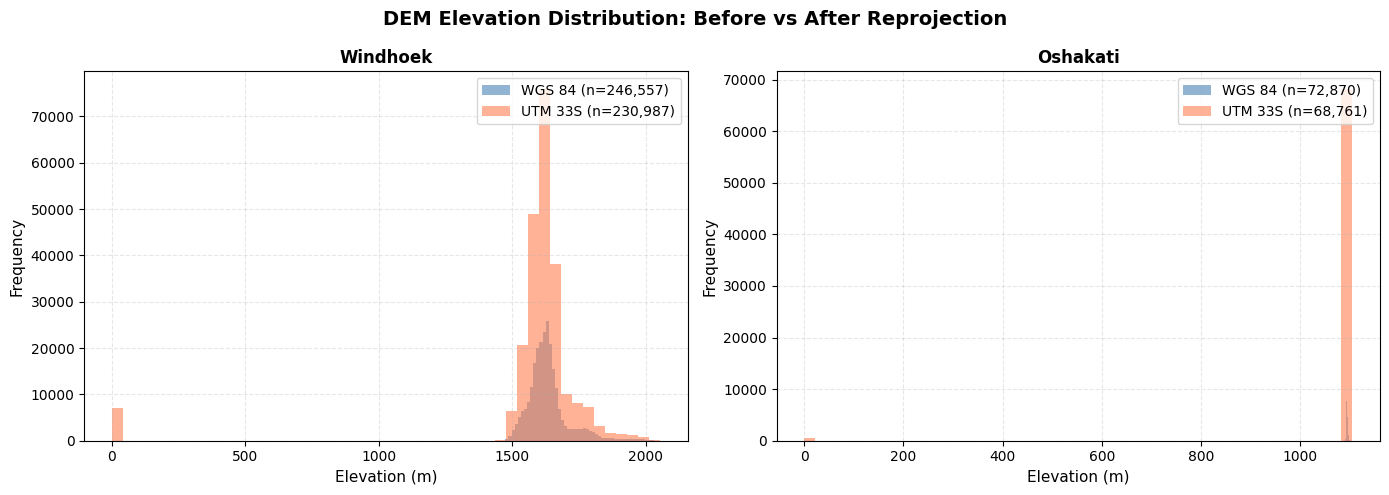


✓ Visualization 1 complete


In [8]:
# Visualization 1: Elevation Histograms (Before and After Reprojection)
print("=" * 70)
print("VISUALIZATION 1: ELEVATION HISTOGRAMS (WGS 84 vs UTM 33S)")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DEM Elevation Distribution: Before vs After Reprojection', fontsize=14, fontweight='bold')

for idx, location_key in enumerate(STUDY_AREAS.keys()):
    ax = axes[idx]
    
    # Load WGS 84 source
    src_path = DATA_RAW / STUDY_AREAS[location_key]
    with rasterio.open(src_path) as src:
        src_data = src.read(1)
        src_valid = src_data[~np.isnan(src_data)]
    
    # Load UTM 33S processed
    if location_key == 'windhoek':
        utm_path = path_windhoek_validated
    else:
        utm_path = path_oshakati_validated
    
    with rasterio.open(utm_path) as utm:
        utm_data = utm.read(1)
        utm_valid = utm_data[utm_data != NODATA_VALUE]
    
    # Plot histograms
    ax.hist(src_valid, bins=50, alpha=0.6, label=f'WGS 84 (n={len(src_valid):,})', color='steelblue')
    ax.hist(utm_valid, bins=50, alpha=0.6, label=f'UTM 33S (n={len(utm_valid):,})', color='coral')
    
    ax.set_xlabel('Elevation (m)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(location_key.capitalize(), fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
fig.savefig(RESULTS_FIGURES / '02_elevation_histograms_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 02_elevation_histograms_comparison.png")
plt.show()

print("\n✓ Visualization 1 complete")

VISUALIZATION 2: SPATIAL ELEVATION MAPS (UTM 33S)
✓ Saved: 02_elevation_maps.png
✓ Saved: 02_elevation_maps.png


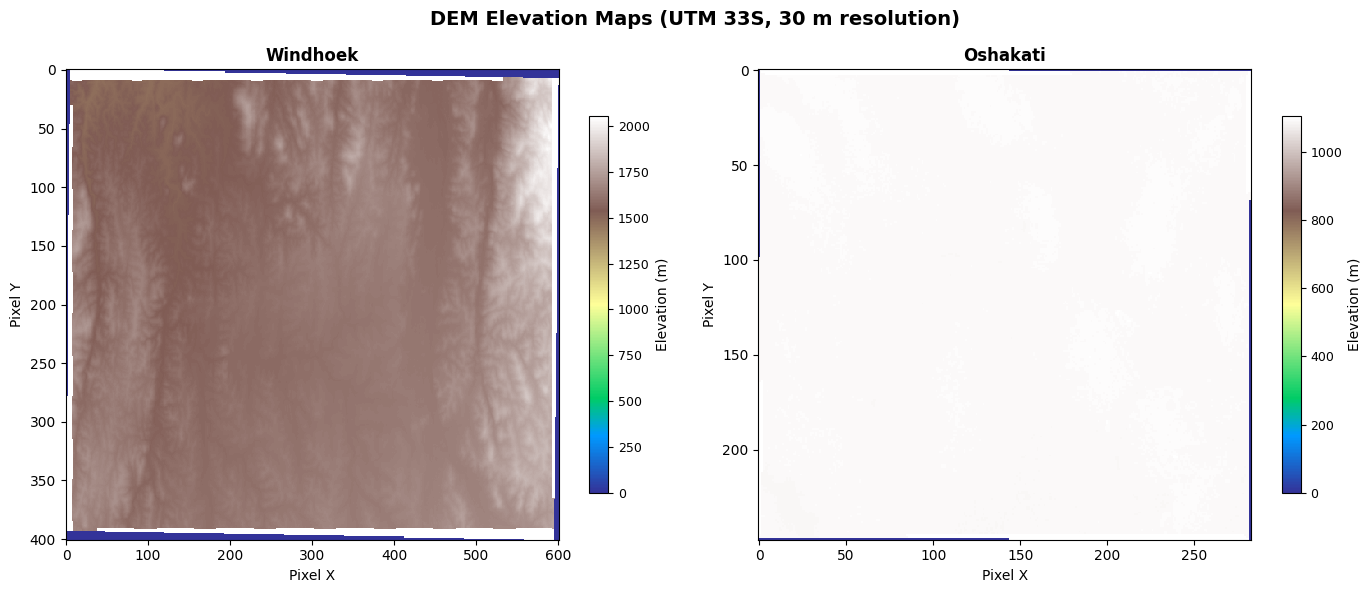


✓ Visualization 2 complete


In [9]:
# Visualization 2: Spatial Elevation Maps (UTM 33S)
print("=" * 70)
print("VISUALIZATION 2: SPATIAL ELEVATION MAPS (UTM 33S)")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('DEM Elevation Maps (UTM 33S, 30 m resolution)', fontsize=14, fontweight='bold')

for idx, location_key in enumerate(STUDY_AREAS.keys()):
    ax = axes[idx]
    
    if location_key == 'windhoek':
        utm_path = path_windhoek_validated
    else:
        utm_path = path_oshakati_validated
    
    with rasterio.open(utm_path) as src:
        dem_data = src.read(1)
        dem_data_masked = np.ma.masked_equal(dem_data, NODATA_VALUE)
    
    # Plot elevation map with colorbar
    im = ax.imshow(dem_data_masked, cmap='terrain', aspect='auto', interpolation='nearest')
    ax.set_title(location_key.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel X', fontsize=10)
    ax.set_ylabel('Pixel Y', fontsize=10)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.8)
    cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
fig.savefig(RESULTS_FIGURES / '02_elevation_maps.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 02_elevation_maps.png")
plt.show()

print("\n✓ Visualization 2 complete")

VISUALIZATION 3: SLOPE HISTOGRAMS (DERIVATIVE INTEGRITY)
✓ Saved: 02_slope_histograms.png
✓ Saved: 02_slope_histograms.png


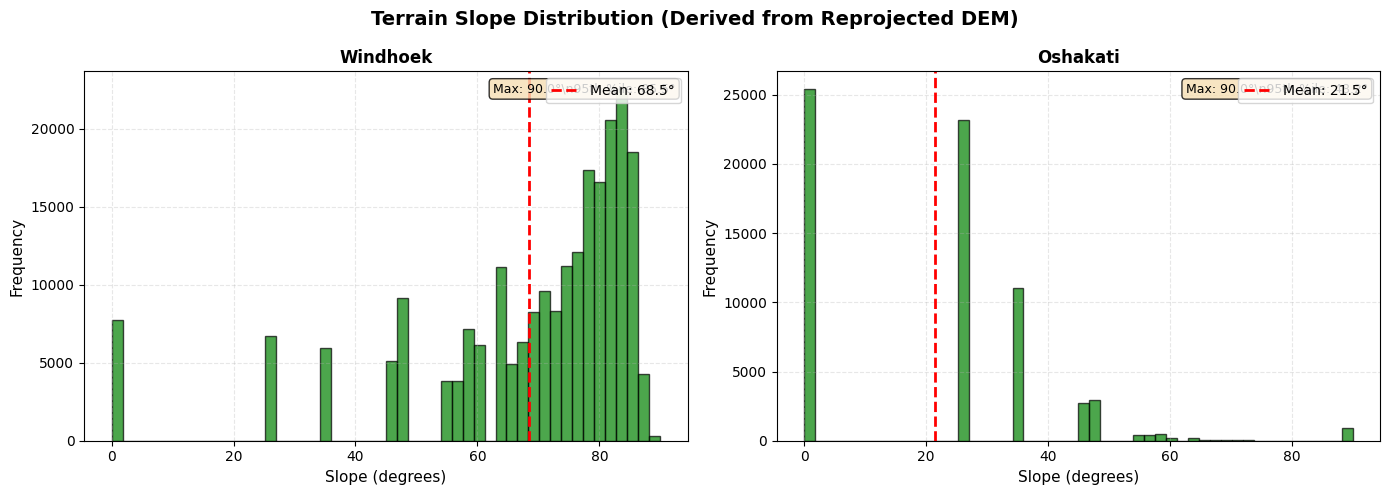


✓ Visualization 3 complete


In [10]:
# Visualization 3: Slope Histograms (Derivative Integrity Check)
print("=" * 70)
print("VISUALIZATION 3: SLOPE HISTOGRAMS (DERIVATIVE INTEGRITY)")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Terrain Slope Distribution (Derived from Reprojected DEM)', fontsize=14, fontweight='bold')

for idx, location_key in enumerate(STUDY_AREAS.keys()):
    ax = axes[idx]
    
    if location_key == 'windhoek':
        utm_path = path_windhoek_validated
    else:
        utm_path = path_oshakati_validated
    
    with rasterio.open(utm_path) as src:
        dem_data = src.read(1)
        dem_valid = dem_data.copy()
        dem_valid[dem_valid == NODATA_VALUE] = np.nan
        
        # Calculate slope using gradient method (D4)
        dy, dx = np.gradient(dem_valid)
        slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
        slope_deg = np.degrees(slope_rad)
        slope_valid = slope_deg[~np.isnan(slope_deg)]
    
    # Plot histogram
    ax.hist(slope_valid, bins=50, color='green', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Slope (degrees)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(location_key.capitalize(), fontsize=12, fontweight='bold')
    
    # Add statistics
    mean_slope = np.mean(slope_valid)
    max_slope = np.max(slope_valid)
    ax.axvline(mean_slope, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_slope:.1f}°')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3, linestyle='--')
    
    # Add text box with stats
    stats_text = f"Max: {max_slope:.1f}°\\n95th %ile: {np.percentile(slope_valid, 95):.1f}°"
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=9)

plt.tight_layout()
fig.savefig(RESULTS_FIGURES / '02_slope_histograms.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 02_slope_histograms.png")
plt.show()

print("\n✓ Visualization 3 complete")

In [11]:
# Export Processing Log (JSON Metadata)
print("=" * 70)
print("EXPORT PROCESSING LOG & METADATA")
print("=" * 70)

processing_log = {
    'timestamp': datetime.now().isoformat(),
    'notebook': '02_Preprocessing_Reprojection',
    'purpose': 'Reproject WGS 84 DEM to UTM 33S with exact 30 m grid enforcement',
    'parameters': {
        'target_crs': TARGET_CRS,
        'target_pixel_size': f'{TARGET_PIXEL_SIZE} m',
        'resampling_method': str(RESAMPLING_METHOD),
        'nodata_value': NODATA_VALUE,
    },
    'source_metadata': {
        location_key: {
            'filename': metadata['filename'],
            'crs': str(metadata['crs']),  # Convert CRS to string for JSON serialization
            'dimensions': f"{metadata['width']} x {metadata['height']} px",
            'elevation_range': f"{metadata['stats']['min']:.2f} - {metadata['stats']['max']:.2f} m",
            'mean_elevation': f"{metadata['stats']['mean']:.2f} m",
            'nodata_percent': f"{metadata['stats']['nan_percent']:.2f}%",
        }
        for location_key, metadata in source_metadata.items()
    },
    'reprojection_results': reprojection_log,
    'nodata_handling': nodata_handling_log,
    'qa_results': {
        location_key: {
            'all_pass': str(result['all_pass']),  # Convert bool to string
            'checks': {k: str(v) for k, v in result['checks'].items()},  # Convert all values to strings
        }
        for location_key, result in qa_results.items()
    },
    'output_files': {
        'windhoek': str(path_windhoek_validated),
        'oshakati': str(path_oshakati_validated),
    },
}

# Save JSON log
log_path = DATA_PROCESSED / 'processing_log_02.json'
with open(log_path, 'w') as f:
    json.dump(processing_log, f, indent=2)

print(f"✓ Processing log saved to: {log_path}")

# Print summary
print("\n" + "=" * 70)
print("PROCESSING SUMMARY")
print("=" * 70)
print(f"Timestamp: {processing_log['timestamp']}")
print(f"Target CRS: {TARGET_CRS}")
print(f"Target pixel size: {TARGET_PIXEL_SIZE} m (enforced exactly)")
print(f"Resampling method: {RESAMPLING_METHOD}")
print(f"NoData value: {NODATA_VALUE}")
print(f"\nOutput files:")
print(f"  - {path_windhoek_validated.name}")
print(f"  - {path_oshakati_validated.name}")
print(f"\nDiagnostic plots:")
print(f"  - 02_elevation_histograms_comparison.png")
print(f"  - 02_elevation_maps.png")
print(f"  - 02_slope_histograms.png")
print(f"\nMetadata log: processing_log_02.json")

# Print QA summary
print("\n" + "=" * 70)
print("QA SUMMARY")
print("=" * 70)
for location_key, result in qa_results.items():
    status = "✓ ALL CHECKS PASS" if result['all_pass'] else "✗ SOME CHECKS FAILED"
    print(f"{location_key.upper()}: {status}")

print("\n✓ Notebook 02 execution complete!")

EXPORT PROCESSING LOG & METADATA
✓ Processing log saved to: /Users/jacobsmacbookpro/Namibia_python/data/processed/processing_log_02.json

PROCESSING SUMMARY
Timestamp: 2026-09-23T11:42:22.761125
Target CRS: EPSG:32733
Target pixel size: 30 m (enforced exactly)
Resampling method: 2
NoData value: -9999

Output files:
  - windhoek_utm33s_validated.tif
  - oshakati_utm33s_validated.tif

Diagnostic plots:
  - 02_elevation_histograms_comparison.png
  - 02_elevation_maps.png
  - 02_slope_histograms.png

Metadata log: processing_log_02.json

QA SUMMARY
WINDHOEK: ✗ SOME CHECKS FAILED
OSHAKATI: ✓ ALL CHECKS PASS

✓ Notebook 02 execution complete!


ERROR 1: PROJ: internal_proj_identify: /Users/jacobsmacbookpro/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/jacobsmacbookpro/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
